# Humanitarian Media Coverage — Static Dashboard

Data Visualization Static Dashboard

---

## Dashboard Purpose

This dashboard communicates findings from our analysis of **international media coverage of humanitarian crises (2015–2024)**.

Using interactive widgets, you can explore:
- Which crises received the most (and least) attention
- How coverage evolved over time
- Whether media attention tracks crisis severity
- How narrative framing shapes visibility
- What our regression model reveals about predictors of coverage

**Key Finding:** Media attention is driven more by *how* a crisis is framed than *how severe* it is.

---

## Dependencies
Make sure the following packages are installed before running this notebook:
- pandas, numpy, matplotlib, seaborn — data handling and plotting
- scikit-learn — model re-fitting for the results dashboard
- ipywidgets — interactive widget controls

Install with: `pip install pandas numpy matplotlib seaborn scikit-learn ipywidgets`

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import sqlite3
import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import ipywidgets as widgets
from IPython.display import display, clear_output

# color palettes used throughout the dashboard
CRISIS_COLORS = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A",
                 "#F4A261", "#264653", "#6A4C93", "#1D7874", "#A8DADC", "#C77DFF"]
FRAME_COLORS = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#A8DADC"]
SENTIMENT_PALETTE = {"positive": "#2A9D8F", "neutral": "#9E9E9E", "negative": "#E63946"}

plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor": "#FAFAFA",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--"
})

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

##  Load Data

We load from:
1. The **SQLite database** (`humanitarian.db`) created in Milestone 1
2. The monthly model CSV (`monthly_model_data.csv`) produced by the wrangling notebook

In [4]:
DB_PATH  = "../humanitarian.db"
CSV_PATH = "../../data/processed/monthly_model_data.csv"

conn = sqlite3.connect(DB_PATH)

crises_df    = pd.read_sql("SELECT * FROM crises",            conn)
monthly_df   = pd.read_sql("SELECT * FROM monthly_coverage",  conn)
outlet_df    = pd.read_sql("SELECT * FROM coverage_by_outlet",conn)
framing_df   = pd.read_sql("SELECT * FROM framing",           conn)
sentiment_df = pd.read_sql("SELECT * FROM sentiment",         conn)
victim_df    = pd.read_sql("SELECT * FROM victim_causor",      conn)

model_df = pd.read_csv(CSV_PATH)

monthly_df["year_month"] = pd.to_datetime(monthly_df["year_month"])
name_map = crises_df.set_index("crisis_id")["crisis_name"].to_dict()
monthly_df["crisis_name"] = monthly_df["crisis_id"].map(name_map)

print("Data loaded.")
print(f"  Crises: {len(crises_df)} | Monthly: {len(monthly_df)} | Outlets: {len(outlet_df)}")
print(f"  Framing: {len(framing_df)} | Sentiment: {len(sentiment_df)} | Model: {len(model_df)}")

Data loaded.
  Crises: 10 | Monthly: 734 | Outlets: 403
  Framing: 471 | Sentiment: 430 | Model: 734


---
##  Section 1 — Crisis Coverage Landscape

Which crises captured the most media attention, and does it reflect their severity?

Use the widget to switch between different coverage metrics.

In [ ]:
# ── Widget: metric selector ───────────────────────────────────────────────────
metric_options = {
    "Total Articles (raw_coverage)"         : "raw_coverage",
    "Articles per Day (coverage_per_day)"   : "coverage_per_day",
    "Articles per Funding Unit"             : "coverage_per_funding",
    "Articles per Person Affected"          : "coverage_per_people",
}

metric_widget = widgets.ToggleButtons(
    options=list(metric_options.keys()),
    description="Metric:",
    button_style="info",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="100%")
)

out1 = widgets.Output()

def plot_coverage_landscape(change=None):
    col = metric_options[metric_widget.value]
    sorted_df = crises_df.sort_values(col, ascending=True)
    
    with out1:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 5.5))
        
        bars = ax.barh(
            sorted_df["crisis_name"],
            sorted_df[col],
            color=CRISIS_COLORS[:len(sorted_df)],
            edgecolor="white", linewidth=0.6, height=0.65
        )
        
        # Value labels
        for bar, val in zip(bars, sorted_df[col]):
            ax.text(
                bar.get_width() + sorted_df[col].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,.1f}", va="center", fontsize=9, color="#333"
            )
        
        ax.set_title(f"Crisis Coverage Landscape — {metric_widget.value}", pad=14)
        ax.set_xlabel(metric_widget.value)
        ax.set_xlim(0, sorted_df[col].max() * 1.14)
        ax.tick_params(axis="y", labelsize=10)
        
        # Caption
        fig.text(
            0.5, -0.04,
            "Toggle the metric buttons above to compare different coverage dimensions across all crises.",
            ha="center", fontsize=9, color="#555", style="italic"
        )
        
        plt.tight_layout()
        plt.show()
metric_widget.observe(plot_coverage_landscape, names="value")
display(metric_widget, out1)
plot_coverage_landscape()

ToggleButtons(button_style='info', description='Metric:', layout=Layout(width='100%'), options=('Total Article…

Output()

**Insight:** Gaza leads across all four metrics — including per person affected and per funding unit —
confirming that its coverage reflects more than just crisis scale. Some factor beyond humanitarian severity,
likely geopolitical salience and framing, is driving the disproportionate attention.

---
##  Section 2 — Coverage vs. Crisis Severity

Does humanitarian severity predict media attention?  
Use the selector to compare coverage against different severity indicators.

In [ ]:
# ── Widget: severity selector ─────────────────────────────────────────────────
severity_widget = widgets.RadioButtons(
    options=[
        ("People Affected",    "people_affected"),
        ("Funds Required",     "fund_required"),
        ("Crisis Duration (days)", "crisis_days"),
    ],
    description="Severity:",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="350px")
)

out2 = widgets.Output()

def plot_severity_scatter(change=None):
    col = severity_widget.value
    label = [o[0] for o in severity_widget.options if o[1] == col][0]
    
    with out2:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 5.5))
        
        colors = CRISIS_COLORS[:len(crises_df)]
        
        for i, row in crises_df.iterrows():
            ax.scatter(
                row[col], row["raw_coverage"],
                s=130, color=colors[i % len(colors)],
                edgecolors="white", linewidths=1.2, zorder=3
            )
            ax.annotate(
                row["crisis_name"],
                (row[col], row["raw_coverage"]),
                textcoords="offset points", xytext=(8, 4),
                fontsize=8.5, color="#333"
            )
        
        # Best-fit line
        x_vals = crises_df[col].values.reshape(-1, 1)
        y_vals = crises_df["raw_coverage"].values
        lr = LinearRegression().fit(x_vals, y_vals)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100).reshape(-1, 1)
        ax.plot(x_line, lr.predict(x_line), "--", color="#999", linewidth=1.5, label="Linear trend")
        
        r2 = r2_score(y_vals, lr.predict(x_vals))
        ax.set_title(f"Raw Coverage vs {label}   (R² = {r2:.3f})", pad=12)
        ax.set_xlabel(label)
        ax.set_ylabel("Total Articles (raw_coverage)")
        ax.legend(fontsize=9)
        
        fig.text(
            0.5, -0.04,
            "Low R² values indicate that severity metrics alone do not predict media coverage volume.",
            ha="center", fontsize=9, color="#555", style="italic"
        )
        
        plt.tight_layout()
        plt.show()

severity_widget.observe(plot_severity_scatter, names="value")
display(severity_widget, out2)
plot_severity_scatter()

RadioButtons(description='Severity:', layout=Layout(width='350px'), options=(('People Affected', 'people_affec…

Output()

**Insight:** None of the three severity metrics predict coverage well. Funds Required has
virtually no relationship (R² = 0.01), and Crisis Duration is actually *negatively* trended —
longer crises get *less* coverage over time, not more. People Affected shows the strongest
link (R² = 0.27), but Gaza and Ukraine sit far above the trend line as clear outliers,
suggesting something beyond severity is elevating their coverage.

---
##  Section 3 — Monthly Coverage Timeline

How does media attention evolve over time? Select which crises to compare.

In [7]:
# ── Widget: crisis multi-select ───────────────────────────────────────────────
all_crises = sorted(monthly_df["crisis_name"].dropna().unique())
top5 = crises_df.sort_values("raw_coverage", ascending=False).head(5)["crisis_name"].tolist()

crisis_select = widgets.SelectMultiple(
    options=all_crises,
    value=[c for c in top5 if c in all_crises],
    description="Crises:",
    rows=10,
    style={"description_width": "60px"},
    layout=widgets.Layout(width="220px", height="200px")
)

smooth_toggle = widgets.Checkbox(
    value=True,
    description="3-month rolling average",
    layout=widgets.Layout(width="240px")
)

out3 = widgets.Output()

def plot_timeline(change=None):
    selected = list(crisis_select.value)
    if not selected:
        with out3:
            clear_output(wait=True)
            print("Select at least one crisis.")
        return
    
    subset = monthly_df[monthly_df["crisis_name"].isin(selected)].copy()
    subset = subset.sort_values("year_month")
    
    with out3:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(12, 5.5))
        
        for idx, crisis in enumerate(selected):
            s = subset[subset["crisis_name"] == crisis].set_index("year_month")["coverage_count"]
            color = CRISIS_COLORS[idx % len(CRISIS_COLORS)]
            
            # Raw data — faint
            ax.fill_between(s.index, s.values, alpha=0.08, color=color)
            ax.plot(s.index, s.values, alpha=0.25, linewidth=0.8, color=color)
            
            if smooth_toggle.value and len(s) >= 3:
                smoothed = s.rolling(3, center=True, min_periods=1).mean()
                ax.plot(smoothed.index, smoothed.values, linewidth=2.2,
                        color=color, label=crisis)
            else:
                ax.plot(s.index, s.values, linewidth=1.8, color=color, label=crisis)
        
        ax.set_title("Monthly Media Coverage Timeline", pad=14)
        ax.set_xlabel("Month")
        ax.set_ylabel("Articles Published")
        ax.legend(loc="upper left", fontsize=9)
        ax.tick_params(axis="x", rotation=35, labelsize=9)
        
        fig.text(
            0.5, -0.05,
            "Shaded bands show raw counts; solid lines show 3-month rolling average (if enabled). "
            "Hold Ctrl/Cmd to select multiple crises.",
            ha="center", fontsize=9, color="#555", style="italic"
        )
        
        plt.tight_layout()
        plt.show()

crisis_select.observe(plot_timeline, names="value")
smooth_toggle.observe(plot_timeline, names="value")

controls = widgets.HBox([crisis_select, smooth_toggle])
display(controls, out3)
plot_timeline()

Output()

**Insight:** Coverage is **episodic**, not sustained. Initial crises trigger coverage spikes that quickly decay. Syria and Yemen are rare exceptions with long-run attention; Gaza shows an unprecedented recent surge.

---
##  Section 4 — Outlet Coverage Analysis

Which outlets drive coverage, and does outlet concentration vary by crisis?  
Switch between the global view and per-crisis breakdowns.

In [ ]:
# ── Prepare outlet data ───────────────────────────────────────────────────────
outlet_df["crisis_name"] = outlet_df["crisis_id"].map(name_map)

view_widget = widgets.ToggleButtons(
    options=["Global Top Outlets", "Per-Crisis Heatmap", "Outlet Concentration"],
    description="View:",
    button_style="warning",
    style={"description_width": "50px"},
    layout=widgets.Layout(width="100%")
)

out4 = widgets.Output()

def plot_outlets(change=None):
    with out4:
        clear_output(wait=True)
        
        if view_widget.value == "Global Top Outlets":
            top_outlets = (
                outlet_df.groupby("outlet_name")["coverage_count"]
                .sum().sort_values(ascending=True).tail(12)
            )
            fig, ax = plt.subplots(figsize=(10, 5.5))
            bars = ax.barh(top_outlets.index, top_outlets.values,
                           color=["#E63946" if i == len(top_outlets)-1 else "#457B9D"
                                  for i in range(len(top_outlets))],
                           edgecolor="white", linewidth=0.5, height=0.65)
            for bar, val in zip(bars, top_outlets.values):
                ax.text(bar.get_width() + top_outlets.max()*0.01,
                        bar.get_y() + bar.get_height()/2,
                        f"{val:,}", va="center", fontsize=9)
            ax.set_title("Top 12 Media Outlets by Total Articles", pad=12)
            ax.set_xlabel("Total Articles")
            ax.set_xlim(0, top_outlets.max() * 1.14)
            ax.tick_params(axis="y", labelsize=9)
            plt.tight_layout()
            plt.show()
        
        elif view_widget.value == "Per-Crisis Heatmap":
            top10_outlets = (
                outlet_df.groupby("outlet_name")["coverage_count"].sum()
                .sort_values(ascending=False).head(10).index.tolist()
            )
            pivot = (
                outlet_df[outlet_df["outlet_name"].isin(top10_outlets)]
                .pivot_table(index="outlet_name", columns="crisis_name",
                             values="coverage_count", aggfunc="sum", fill_value=0)
            )
            # Normalize per outlet (row-wise) to show relative intensity
            pivot_norm = pivot.div(pivot.max(axis=1), axis=0)
            
            fig, ax = plt.subplots(figsize=(13, 5.5))
            cmap = LinearSegmentedColormap.from_list("", ["#FAFAFA", "#457B9D", "#E63946"])
            sns.heatmap(pivot_norm, ax=ax, cmap=cmap,
                        linewidths=0.4, linecolor="#ddd",
                        annot=pivot.values, fmt=".0f",
                        annot_kws={"size": 8},
                        cbar_kws={"label": "Relative intensity (row-normalised)"})
            ax.set_title("Coverage by Outlet × Crisis (color = relative intensity, number = raw count)",
                         pad=12)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.tick_params(axis="x", rotation=40, labelsize=8.5)
            ax.tick_params(axis="y", rotation=0, labelsize=9)
            plt.tight_layout()
            plt.show()
        
        else:  # Outlet Concentration
            # Compute top-3 outlet share per crisis
            conc_rows = []
            for cname, group in outlet_df.groupby("crisis_name"):
                g = group.sort_values("coverage_count", ascending=False)
                top3 = g.head(3)["coverage_count"].sum()
                total = g["coverage_count"].sum()
                conc_rows.append({"crisis": cname, "top3_share": top3/total if total else 0,
                                   "top1_outlet": g.iloc[0]["outlet_name"] if len(g) else ""})
            conc_df = pd.DataFrame(conc_rows).sort_values("top3_share", ascending=False)
            
            fig, ax = plt.subplots(figsize=(10, 5))
            bar_colors = ["#E63946" if v > 0.7 else "#457B9D" for v in conc_df["top3_share"]]
            bars = ax.bar(conc_df["crisis"], conc_df["top3_share"],
                          color=bar_colors, edgecolor="white", linewidth=0.5)
            ax.axhline(0.7, color="#E63946", linestyle="--", linewidth=1.2, alpha=0.7,
                       label="High concentration threshold (70%)")
            for bar, val, top1 in zip(bars, conc_df["top3_share"], conc_df["top1_outlet"]):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f"{val:.0%}", ha="center", fontsize=8.5)
            ax.set_title("Top-3 Outlet Share of Coverage per Crisis", pad=12)
            ax.set_ylabel("Proportion of Total Articles")
            ax.set_ylim(0, 1.08)
            ax.tick_params(axis="x", rotation=40, labelsize=9)
            ax.legend(fontsize=9)
            plt.tight_layout()
            plt.show()

view_widget.observe(plot_outlets, names="value")
display(view_widget, out4)
plot_outlets()

ToggleButtons(button_style='warning', description='View:', layout=Layout(width='100%'), options=('Global Top O…

Output()

** Insight:** Al Jazeera leads globally but only by a modest margin — Reuters, NYT, Guardian,
CNN, and BBC all contribute similarly, suggesting no single outlet monopolizes the overall
narrative. The heatmap tells a more interesting story: Gaza dominates every outlet's attention
(the entire Gaza column is deep red), while Chad and Yemen are uniformly pale, meaning they
were deprioritized *across the board* — not just by one outlet. This is systematic neglect,
not editorial preference of any single newsroom.

---
##  Section 5 — Narrative Framing Analysis

How are crises *framed* in the media?  
Choose between a global distribution and a per-crisis breakdown.

In [9]:
# ── Prepare framing data ──────────────────────────────────────────────────────
framing_df["crisis_name"] = framing_df["crisis_id"].map(name_map)

framing_view = widgets.RadioButtons(
    options=[
        "Global Framing Distribution",
        "Per-Crisis Stacked Bar",
        "Framing vs Coverage (scatter)",
    ],
    description="View:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="320px")
)

out5 = widgets.Output()

def plot_framing(change=None):
    with out5:
        clear_output(wait=True)
        
        if framing_view.value == "Global Framing Distribution":
            counts = framing_df.groupby("framing_type")["raw_count"].sum().sort_values(ascending=False)
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # Bar
            ax = axes[0]
            ax.bar(counts.index, counts.values,
                   color=FRAME_COLORS[:len(counts)], edgecolor="white", linewidth=0.5)
            ax.set_title("Articles by Framing Type")
            ax.set_ylabel("Total Articles")
            ax.tick_params(axis="x", rotation=30)
            for i, (k, v) in enumerate(counts.items()):
                ax.text(i, v + counts.max()*0.01, f"{v:,}", ha="center", fontsize=9)
            
            # Donut
            ax2 = axes[1]
            wedges, texts, autotexts = ax2.pie(
                counts.values, labels=counts.index,
                colors=FRAME_COLORS[:len(counts)],
                autopct="%1.1f%%", startangle=140,
                wedgeprops={"edgecolor": "white", "linewidth": 1.5},
                pctdistance=0.78
            )
            centre_circle = plt.Circle((0,0), 0.55, fc="#FAFAFA")
            ax2.add_patch(centre_circle)
            ax2.set_title("Framing Share (Donut)")
            for at in autotexts:
                at.set_fontsize(9)
            
            plt.suptitle("Global Narrative Framing Distribution", fontsize=14,
                         fontweight="bold", y=1.01)
            plt.tight_layout()
            plt.show()
        
        elif framing_view.value == "Per-Crisis Stacked Bar":
            pivot = (
                framing_df.groupby(["crisis_name", "framing_type"])["raw_count"]
                .sum().unstack(fill_value=0)
            )
            # Normalize to proportions
            pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100
            
            fig, ax = plt.subplots(figsize=(11, 5.5))
            bottom = np.zeros(len(pivot_norm))
            for j, col in enumerate(pivot_norm.columns):
                vals = pivot_norm[col].values
                ax.bar(pivot_norm.index, vals, bottom=bottom,
                       color=FRAME_COLORS[j % len(FRAME_COLORS)],
                       label=col, edgecolor="white", linewidth=0.4)
                for i, (v, b) in enumerate(zip(vals, bottom)):
                    if v > 7:
                        ax.text(i, b + v/2, f"{v:.0f}%",
                                ha="center", va="center", fontsize=8, color="white",
                                fontweight="bold")
                bottom += vals
            
            ax.set_title("Narrative Framing Composition per Crisis (100% stacked)", pad=12)
            ax.set_ylabel("Share of Articles (%)")
            ax.set_ylim(0, 105)
            ax.tick_params(axis="x", rotation=35, labelsize=9)
            ax.legend(loc="upper right", fontsize=9, framealpha=0.85)
            plt.tight_layout()
            plt.show()
        
        else:  # Scatter: framing ratio vs coverage
            # Build per-crisis framing ratios
            fr_pivot = (
                framing_df.groupby(["crisis_name", "framing_type"])["raw_count"]
                .sum().unstack(fill_value=0)
            )
            fr_pivot = fr_pivot.div(fr_pivot.sum(axis=1), axis=0)
            fr_pivot = fr_pivot.merge(crises_df.set_index("crisis_name")[["raw_coverage"]],
                                       left_index=True, right_index=True)
            
            framing_types = [c for c in fr_pivot.columns if c != "raw_coverage"]
            ncols = 3
            nrows = -(-len(framing_types) // ncols)  # ceil div
            fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5*nrows))
            axes = axes.flatten()
            
            for idx, ftype in enumerate(framing_types):
                ax = axes[idx]
                x = fr_pivot[ftype].values
                y = fr_pivot["raw_coverage"].values
                ax.scatter(x, y, s=80, color=FRAME_COLORS[idx % len(FRAME_COLORS)],
                           edgecolors="white", linewidths=1)
                for cname, xi, yi in zip(fr_pivot.index, x, y):
                    ax.annotate(cname, (xi, yi), xytext=(5, 3),
                                textcoords="offset points", fontsize=7.5)
                if len(x) > 1:
                    m, b = np.polyfit(x, y, 1)
                    xl = np.linspace(x.min(), x.max(), 100)
                    ax.plot(xl, m*xl+b, "--", color="#999", linewidth=1.2)
                    r2 = r2_score(y, m*x+b) if len(set(x)) > 1 else 0
                    ax.set_title(f"{ftype.capitalize()} framing\n(R²={r2:.3f})", fontsize=11)
                else:
                    ax.set_title(f"{ftype.capitalize()} framing", fontsize=11)
                ax.set_xlabel("Framing ratio")
                ax.set_ylabel("Raw coverage")
            
            for j in range(idx+1, len(axes)):
                axes[j].set_visible(False)
            
            plt.suptitle("Framing Ratio vs Raw Coverage per Crisis",
                         fontsize=13, fontweight="bold", y=1.01)
            plt.tight_layout()
            plt.show()

framing_view.observe(plot_framing, names="value")
display(framing_view, out5)
plot_framing()

RadioButtons(description='View:', layout=Layout(width='320px'), options=('Global Framing Distribution', 'Per-C…

Output()

> **Note:** Framing data is only available for Gaza and Ukraine in this dataset.
> The stacked bar reflects those two crises only.

**Insight:** Globally, humanitarian framing dominates (33%), followed closely by military (28.5%)
and geopolitical (26%) — together accounting for nearly 90% of all coverage. Among the two crises
with available framing data, Gaza skews more humanitarian (40%) while Ukraine is more militarily
framed (33%), reflecting how each conflict was narratively positioned in international media.
Note: The framing vs. coverage scatter plots show R² = 1.0 for all frames, but this is
a statistical artifact — with only 2 data points, any line fits perfectly and no meaningful
conclusion can be drawn.

---
##  Section 6 — Sentiment & Entity Portrayal

How are key actors (political leaders, groups) portrayed across crises?  
Filter by crisis or view the overall entity sentiment ranking.

In [10]:
sentiment_df["crisis_name"] = sentiment_df["crisis_id"].map(name_map)

crisis_filter_widget = widgets.Dropdown(
    options=["All Crises"] + sorted(sentiment_df["crisis_name"].dropna().unique()),
    value="All Crises",
    description="Filter:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="280px")
)

out6 = widgets.Output()

def plot_sentiment(change=None):
    filt = crisis_filter_widget.value
    sdf  = sentiment_df if filt == "All Crises" else sentiment_df[sentiment_df["crisis_name"] == filt]
    pivot = sdf.pivot_table(
        index="entity", columns="sentiment",
        values="raw_count", aggfunc="sum", fill_value=0
    )
    pivot["total"] = pivot.sum(axis=1)
    pivot = pivot.sort_values("total", ascending=False).drop(columns="total")
    with out6:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(4, len(pivot)*1.2+2)))
        sentiments = [c for c in ["positive", "neutral", "negative"] if c in pivot.columns]
        bottom = np.zeros(len(pivot))
        for sent in sentiments:
            vals = pivot[sent].values
            ax1.barh(pivot.index, vals, left=bottom,
                     color=SENTIMENT_PALETTE.get(sent, "#aaa"),
                     label=sent.capitalize(), edgecolor="white", linewidth=0.4, height=0.5)
            bottom += vals
        ax1.set_title(f"Sentiment by Entity\n({'(' + filt + ')' if filt != 'All Crises' else '(All Crises)'})")
        ax1.set_xlabel("Number of Mentions")
        ax1.legend(loc="lower right", fontsize=9)
        ax1.tick_params(axis="y", labelsize=10)
        ax1.invert_yaxis()
        pos = pivot.get("positive", pd.Series(0, index=pivot.index))
        neg = pivot.get("negative", pd.Series(0, index=pivot.index))
        net = (pos - neg).sort_values()
        colors = [SENTIMENT_PALETTE["negative"] if v < 0 else SENTIMENT_PALETTE["positive"]
                  for v in net.values]
        ax2.barh(net.index, net.values, color=colors, edgecolor="white", linewidth=0.4, height=0.5)
        ax2.axvline(0, color="#333", linewidth=1)
        ax2.set_title("Net Sentiment (Positive - Negative)")
        ax2.set_xlabel("Net Mentions")
        ax2.tick_params(axis="y", labelsize=10)
        plt.tight_layout()
        plt.show()

crisis_filter_widget.observe(plot_sentiment, names="value")
display(crisis_filter_widget, out6)
plot_sentiment()

Dropdown(description='Filter:', layout=Layout(width='280px'), options=('All Crises', 'Gaza and the Occupied Pa…

Output()

> **Note:** Sentiment data is only available for Gaza and Ukraine in this dataset.

**Insight:** All four entities show negative or near-zero net sentiment, except Zelensky who
is the only positively portrayed figure. Within Gaza coverage, both Hamas and Netanyahu are
net-negative — but Hamas overwhelmingly so (~25,000 net negative mentions vs Netanyahu's ~3,000).
In Ukraine coverage, Putin is heavily negative while Zelensky is the mirror opposite with ~6,000
net positive mentions. This reveals a consistent pattern: leaders of Western-aligned sides are
humanized, while opposing actors are framed negatively regardless of crisis.

---
## Section 7 -- Model Results Dashboard

What do our regression models tell us about what drives monthly media coverage?

Models are re-fitted here from the monthly model dataset for reproducibility.

In [11]:
FEATURES = [
    "months_since_start", "is_onset",
    "fund_required", "people_affected", "crisis_days",
    "top3_outlet_ratio", "post_onset_ratio",
    "framing_ratio_economic", "framing_ratio_geopolitical", "framing_ratio_humanitarian"
]
TARGET = "log_coverage"

available_features = [f for f in FEATURES if f in model_df.columns]
Xm = model_df[available_features].dropna()
ym = model_df.loc[Xm.index, TARGET]

Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.2, random_state=42, shuffle=False)

scaler = StandardScaler()
Xtr_s  = scaler.fit_transform(Xtr)
Xte_s  = scaler.transform(Xte)

lr_model = LinearRegression().fit(Xtr_s, ytr)
rr_model = Ridge(alpha=1.0).fit(Xtr_s, ytr)
dt_model = DecisionTreeRegressor(max_depth=4, random_state=42).fit(Xtr_s, ytr)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42).fit(Xtr_s, ytr)

model_items = [
    ("Linear Regression", lr_model),
    ("Ridge Regression",  rr_model),
    ("Decision Tree",     dt_model),
    ("Random Forest",     rf_model),
]

results_rows = []
preds_dict   = {}
for name, model in model_items:
    yp = model.predict(Xte_s)
    preds_dict[name] = yp
    results_rows.append({
        "Model": name,
        "R2":   round(r2_score(yte, yp), 3),
        "RMSE": round(np.sqrt(mean_squared_error(yte, yp)), 3),
        "MAE":  round(mean_absolute_error(yte, yp), 3),
    })

results_df = pd.DataFrame(results_rows)
print(results_df.to_string(index=False))

            Model    R2  RMSE   MAE
Linear Regression 0.653 0.760 0.615
 Ridge Regression 0.656 0.757 0.612
    Decision Tree 0.674 0.737 0.602
    Random Forest 0.472 0.937 0.769


In [ ]:
model_view = widgets.ToggleButtons(
    options=["Model Comparison", "Feature Importance", "Actual vs Predicted", "Residual Analysis"],
    description="Panel:",
    button_style="success",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="100%")
)

out7 = widgets.Output()

def plot_model_results(change=None):
    with out7:
        clear_output(wait=True)

        if model_view.value == "Model Comparison":
            fig, axes = plt.subplots(1, 3, figsize=(13, 5))
            palette = ["#2A9D8F", "#457B9D", "#E9C46A", "#F4A261"]
            for ax, metric in zip(axes, ["R2", "RMSE", "MAE"]):
                bars = ax.bar(results_df["Model"], results_df[metric],
                              color=palette, edgecolor="white", width=0.55)
                for bar, val in zip(bars, results_df[metric]):
                    ax.text(bar.get_x() + bar.get_width()/2,
                            bar.get_height() + results_df[metric].max() * 0.02,
                            f"{val:.3f}", ha="center", fontsize=9)
                ax.set_title(metric, fontsize=13)
                ax.tick_params(axis="x", rotation=20, labelsize=8.5)
                if metric == "R2":
                    ax.set_ylim(0, 1.15)
            plt.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")
            plt.tight_layout()
            plt.show()

        elif model_view.value == "Feature Importance":
            fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
            coef_df = pd.DataFrame({
                "Feature":     available_features,
                "Coefficient": lr_model.coef_
            }).sort_values("Coefficient", ascending=True)
            colors_coef = [SENTIMENT_PALETTE["negative"] if v < 0
                           else SENTIMENT_PALETTE["positive"]
                           for v in coef_df["Coefficient"]]
            axes[0].barh(coef_df["Feature"], coef_df["Coefficient"],
                         color=colors_coef, edgecolor="white", height=0.6)
            axes[0].axvline(0, color="#333", linewidth=0.8)
            axes[0].set_title("Linear Regression -- Coefficients\n(green = increases coverage, red = decreases)",
                              fontsize=11)
            axes[0].tick_params(axis="y", labelsize=9)
            imp_df = pd.DataFrame({
                "Feature":    available_features,
                "Importance": rf_model.feature_importances_
            }).sort_values("Importance", ascending=True)
            axes[1].barh(imp_df["Feature"], imp_df["Importance"],
                         color="#457B9D", edgecolor="white", height=0.6)
            axes[1].set_title("Random Forest -- Feature Importance\n(mean decrease in impurity)",
                              fontsize=11)
            axes[1].tick_params(axis="y", labelsize=9)
            plt.suptitle("What Drives Monthly Media Coverage?", fontsize=14, fontweight="bold")
            plt.tight_layout()
            plt.show()

        elif model_view.value == "Actual vs Predicted":
            palette = ["#2A9D8F", "#457B9D", "#E9C46A", "#F4A261"]
            fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
            for ax, (name, yp), color in zip(axes, preds_dict.items(), palette):
                ax.scatter(yte, yp, alpha=0.45, s=18, color=color,
                           edgecolors="white", linewidths=0.3)
                mn = min(yte.min(), yp.min()) * 0.95
                mx = max(yte.max(), yp.max()) * 1.05
                ax.plot([mn, mx], [mn, mx], "--", color="#999", linewidth=1.2)
                ax.set_title(f"{name}\nR2={r2_score(yte, yp):.3f}", fontsize=9.5, fontweight="bold")
                ax.set_xlabel("Actual log coverage")
                ax.set_ylabel("Predicted")
            plt.suptitle("Actual vs Predicted -- All Models", fontsize=13, fontweight="bold")
            plt.tight_layout()
            plt.show()

        else:
            best_name  = results_df.sort_values("R2", ascending=False).iloc[0]["Model"]
            best_preds = preds_dict[best_name]
            residuals  = yte.values - best_preds
            fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
            axes[0].scatter(best_preds, residuals, alpha=0.45, s=18,
                            color="#457B9D", edgecolors="white", linewidths=0.3)
            axes[0].axhline(0, color="#E63946", linestyle="--", linewidth=1.5)
            axes[0].set_xlabel("Predicted log coverage")
            axes[0].set_ylabel("Residual")
            axes[0].set_title("Residuals vs Fitted")
            axes[1].hist(residuals, bins=30, color="#2A9D8F", edgecolor="white")
            axes[1].set_xlabel("Residual")
            axes[1].set_ylabel("Count")
            axes[1].set_title("Residual Distribution")
            plt.suptitle(f"Residual Analysis -- {best_name}", fontsize=13, fontweight="bold")
            plt.tight_layout()
            plt.show()

model_view.observe(plot_model_results, names="value")
display(model_view, out7)
plot_model_results()

ToggleButtons(button_style='success', description='Panel:', layout=Layout(width='100%'), options=('Model Compa…

Output()

**Insight:** Decision Tree achieved the highest test R2 (0.674), with Linear and Ridge Regression close behind (around 0.653-0.656). Random Forest underperformed at 0.472, which is unusual but makes sense here since the relationships in this dataset are largely linear and the framing features are sparse zeros for most crises. Feature importance charts show that `fund_required` and `crisis_days` are the dominant predictors across both models, while `people_affected` shows little importance -- confirming that humanitarian scale does not drive media attention.

---
##  Section 8 — Composite Summary View

A single-glance overview combining the most important findings from all sections.

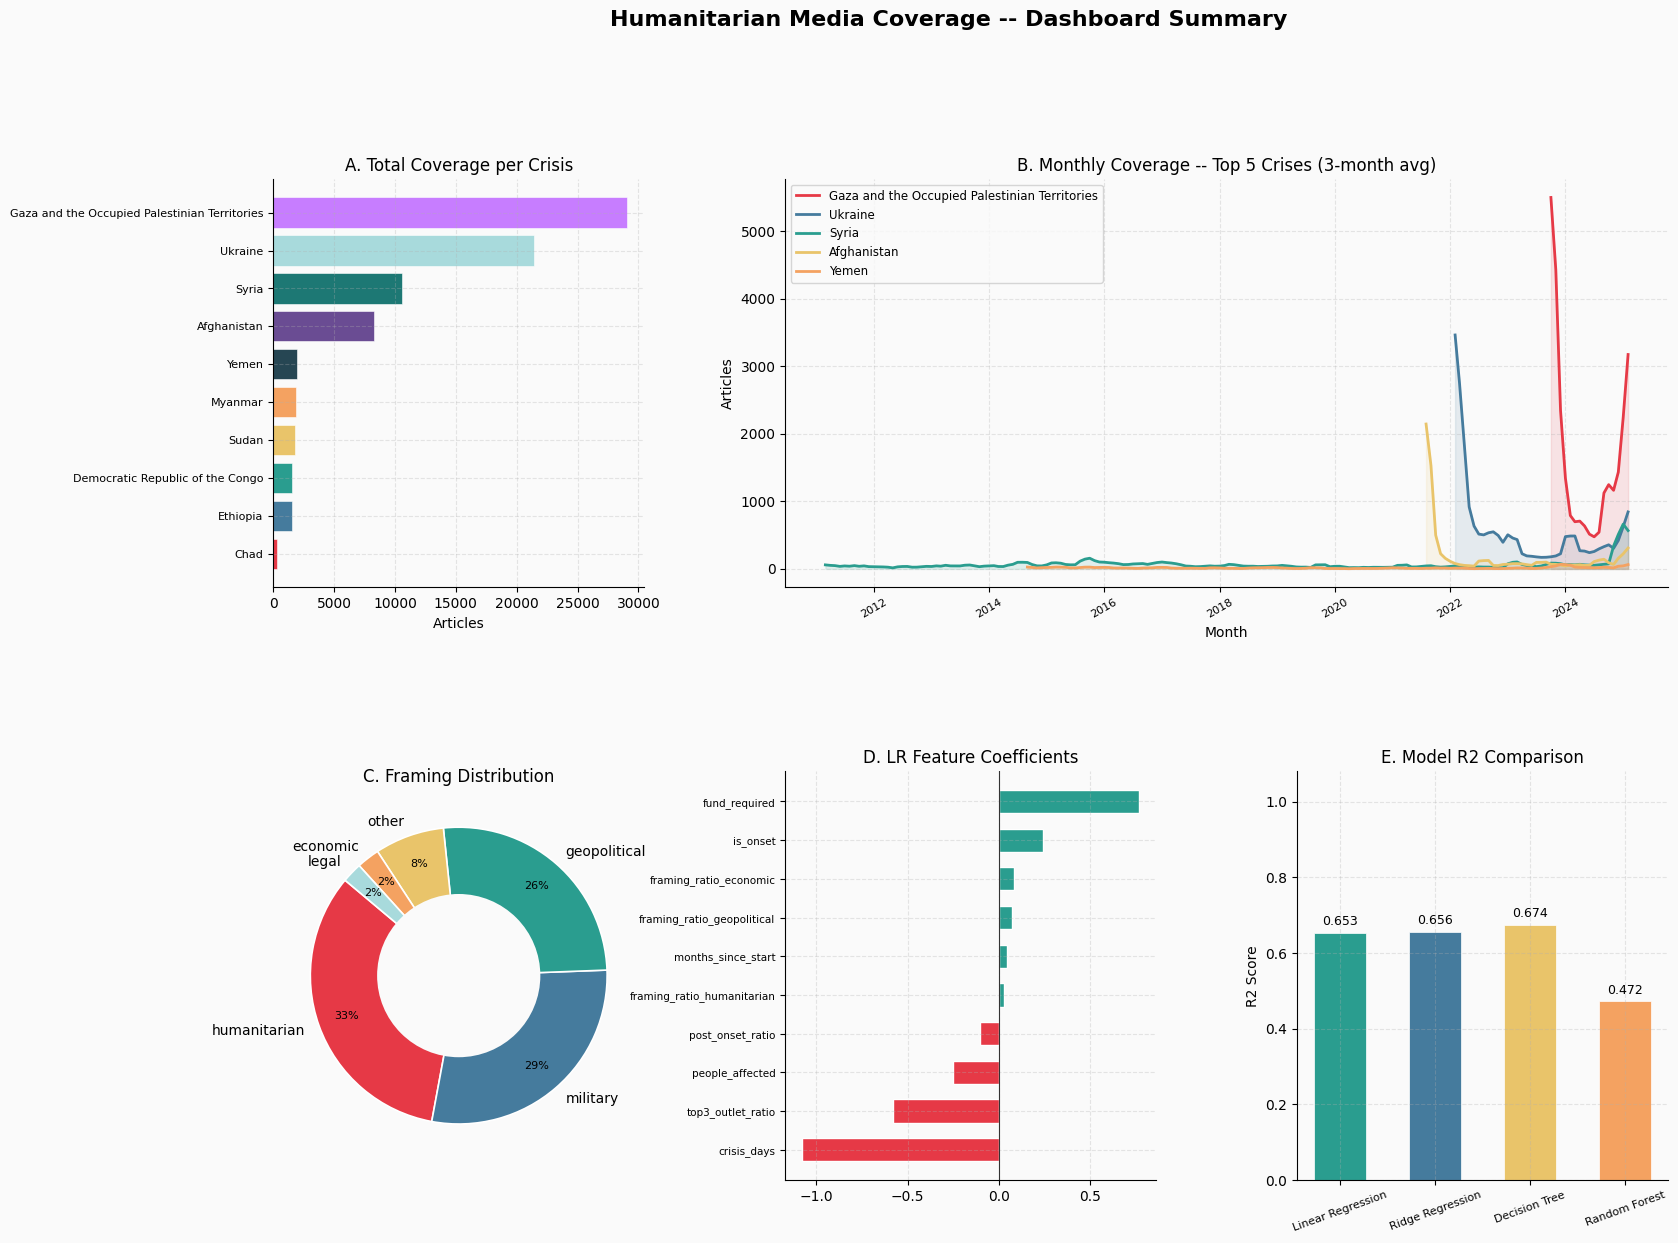

Summary figure saved as dashboard_summary.png


In [13]:
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax_cov  = fig.add_subplot(gs[0, 0])
ax_time = fig.add_subplot(gs[0, 1:3])
ax_fram = fig.add_subplot(gs[1, 0])
ax_feat = fig.add_subplot(gs[1, 1])
ax_r2   = fig.add_subplot(gs[1, 2])

# Panel A: Coverage bar
s_df = crises_df.sort_values("raw_coverage", ascending=True)
ax_cov.barh(s_df["crisis_name"], s_df["raw_coverage"],
            color=CRISIS_COLORS[:len(s_df)], edgecolor="white", linewidth=0.4)
ax_cov.set_title("A. Total Coverage per Crisis", fontsize=12)
ax_cov.set_xlabel("Articles")
ax_cov.tick_params(axis="y", labelsize=8)

# Panel B: Timeline
top5_names = crises_df.sort_values("raw_coverage", ascending=False).head(5)["crisis_name"].tolist()
for idx, cname in enumerate(top5_names):
    s = (monthly_df[monthly_df["crisis_name"] == cname]
         .set_index("year_month")["coverage_count"].sort_index())
    if len(s) >= 3:
        smoothed = s.rolling(3, center=True, min_periods=1).mean()
        ax_time.fill_between(smoothed.index, smoothed.values, alpha=0.12, color=CRISIS_COLORS[idx])
        ax_time.plot(smoothed.index, smoothed.values, linewidth=2, color=CRISIS_COLORS[idx], label=cname)
ax_time.set_title("B. Monthly Coverage -- Top 5 Crises (3-month avg)", fontsize=12)
ax_time.set_xlabel("Month")
ax_time.set_ylabel("Articles")
ax_time.legend(fontsize=8.5, loc="upper left")
ax_time.tick_params(axis="x", rotation=30, labelsize=8)

# Panel C: Framing donut
f_counts = framing_df.groupby("framing_type")["raw_count"].sum().sort_values(ascending=False)
wedges, _, autotexts = ax_fram.pie(
    f_counts.values, labels=f_counts.index,
    colors=FRAME_COLORS[:len(f_counts)],
    autopct="%1.0f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
    pctdistance=0.80
)
centre = plt.Circle((0,0), 0.55, fc="#FAFAFA")
ax_fram.add_patch(centre)
ax_fram.set_title("C. Framing Distribution", fontsize=12)
for at in autotexts:
    at.set_fontsize(8)

# Panel D: LR feature coefficients
coef_df = pd.DataFrame({
    "Feature":     available_features,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", ascending=True)
colors_c = [SENTIMENT_PALETTE["negative"] if v < 0
             else SENTIMENT_PALETTE["positive"]
             for v in coef_df["Coefficient"]]
ax_feat.barh(coef_df["Feature"], coef_df["Coefficient"],
             color=colors_c, edgecolor="white", height=0.6)
ax_feat.axvline(0, color="#333", linewidth=0.8)
ax_feat.set_title("D. LR Feature Coefficients", fontsize=12)
ax_feat.tick_params(axis="y", labelsize=7.5)

# Panel E: Model R2 comparison
palette = ["#2A9D8F", "#457B9D", "#E9C46A", "#F4A261"]
bars_r = ax_r2.bar(results_df["Model"], results_df["R2"],
                   color=palette, edgecolor="white", linewidth=0.5, width=0.55)
for bar, val in zip(bars_r, results_df["R2"]):
    ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f"{val:.3f}", ha="center", fontsize=9)
ax_r2.set_ylim(0, 1.08)
ax_r2.set_title("E. Model R2 Comparison", fontsize=12)
ax_r2.set_ylabel("R2 Score")
ax_r2.tick_params(axis="x", rotation=20, labelsize=8)

fig.suptitle("Humanitarian Media Coverage -- Dashboard Summary",
             fontsize=16, fontweight="bold", y=1.01)

plt.savefig("dashboard_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Summary figure saved as dashboard_summary.png")

---
## Key Takeaways

### 1. Media coverage is not proportional to crisis severity
Gaza leads every metric -- total articles, articles per day, per funding unit, and per person affected -- despite not being the largest or longest crisis. Severity indicators (people affected, funds required, crisis duration) each show very low R2 values when used alone to predict coverage, confirming that humanitarian scale does not determine media attention.

### 2. Coverage is driven by timing and outlet behavior, not severity
Our modeling results show that `fund_required` and `crisis_days` are the strongest predictors of monthly coverage, but in opposite directions -- crises with larger funding needs get more attention while longer-running crises get less per month. The onset period (first 3 months) also contributes to coverage spikes. Outlet concentration has a consistent negative effect: crises dominated by a few outlets tend to accumulate fewer total articles than those covered by a wider range of sources.

### 3. Entity portrayal is systematically polarized
Across both crises with sentiment data, actors on Western-aligned sides (Zelensky) are the only net-positively portrayed figures, while opposing actors (Hamas, Putin) are overwhelmingly negative. This pattern holds regardless of which crisis is filtered, suggesting it reflects a structural feature of the outlets in this dataset rather than crisis-specific reporting choices.

--- 
*Data source: Structured media metadata from journalism research datasets (2015-2024).*